In [1]:
import os
import sys
import json
import logging
from typing import List
from langchain_core.documents import Document

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

from src.rag.generator import ScholarshipGenerator
from src.schemas.student import StudentProfile

logging.basicConfig(level=logging.INFO, format='%(levelname)s - %(message)s')

class DummyMessage:
    """Mock class for chat history messages."""
    def __init__(self, role: str, content: str):
        self.role = role
        self.content = content

def run_generator_evaluation():
    """
    Executes a comprehensive, isolated testing suite for the Generation Layer (LLM).
    Uses hardcoded dummy contexts to enforce strict hallucination checks, 
    smart filtering validation, and JSON formatting compliance.
    """
    logging.info("Initializing Generation Evaluation Suite...")
    
    try:
        generator = ScholarshipGenerator()
    except Exception as e:
        logging.error("Failed to initialize Generator. Check Groq API key: %s", str(e))
        return

    # ---------------------------------------------------------
    # TEST 1: Zero Hallucination & Strict Link Enforcement
    # ---------------------------------------------------------
    logging.info("--- TEST 1: Zero Hallucination & Links ---")
    dummy_doc_1 = Document(
        page_content="The application process requires sending an email to our dummy server. No other documents are needed.",
        metadata={
            "scholarship_name": "Galaxy Research Fake Grant",
            "host_country": "Mars",
            "funding_category": "Fully Funded",
            "funding_amount": "$99,000",
            "standardized_deadline": "2099-12-31",
            "application_link": "https://www.galaxy-fake-grant.org/apply-now"
        }
    )
    
    # Updated: Passed all required fields for Pydantic validation
    profile_1 = StudentProfile(
        nationality="Egyptian",
        academic_level="Master",
        academic_major="Astronomy",
        gpa=3.8,
        target_countries=[],
        skills=[]
    )
    
    query_1 = "How can I apply for this grant and what is the official link?"
    response_1 = generator.generate_response(profile_1, [dummy_doc_1], query_1)
    
    print("\n[Query]:", query_1)
    print("[Response]:\n", response_1)
    print("-" * 60)

    # ---------------------------------------------------------
    # TEST 2: Smart Filtering (Master vs PhD conditions)
    # ---------------------------------------------------------
    logging.info("--- TEST 2: Smart Filtering (Roleplay Orchestrator) ---")
    dummy_doc_2 = Document(
        page_content="REQUIREMENTS: If you are a Master student, you need 2 recommendation letters and a CV. If you are a PhD or Postdoc student, you MUST submit a 50-page dissertation proposal and a postdoctoral host invitation.",
        metadata={
            "scholarship_name": "Complex Academic Fellowship",
            "host_country": "Germany"
        }
    )
    
    profile_2 = {"academic_major": "Physics", "academic_level": "Master", "nationality": "Syrian"}
    query_2 = "What documents do I need to prepare for this fellowship?"
    
    response_2 = generator.chat_orchestrator(
        profile_data=profile_2,
        chat_history=[],
        retrieved_docs=[dummy_doc_2],
        user_message=query_2,
        intent="explain"
    )
    
    print("\n[Query]:", query_2)
    print("[Profile Level]:", profile_2['academic_level'])
    print("[Response] (Should ONLY mention letters and CV, NO dissertation):\n", response_2)
    print("-" * 60)

    # ---------------------------------------------------------
    # TEST 3: Intent Handling (Markdown Comparison Table)
    # ---------------------------------------------------------
    logging.info("--- TEST 3: Intent Handling (Compare) ---")
    dummy_doc_3 = Document(
        page_content="A great grant for tech students.",
        metadata={"scholarship_name": "Tech Alpha", "funding_amount": "$10,000", "standardized_deadline": "2026-05-01"}
    )
    dummy_doc_4 = Document(
        page_content="Another grant for tech students.",
        metadata={"scholarship_name": "Tech Beta", "funding_amount": "Full Tuition", "standardized_deadline": "2026-08-15"}
    )
    
    response_3 = generator.chat_orchestrator(
        profile_data=profile_2,
        chat_history=[DummyMessage("user", "I found two scholarships.")],
        retrieved_docs=[dummy_doc_3, dummy_doc_4],
        user_message="Can you compare Tech Alpha and Tech Beta?",
        intent="compare"
    )
    
    print("\n[Response] (Should be a formatted Markdown Table):\n", response_3)
    print("-" * 60)

    # ---------------------------------------------------------
    # TEST 4: CV Parsing & JSON Strictness
    # ---------------------------------------------------------
    logging.info("--- TEST 4: CV Parsing (JSON Formatting) ---")
    messy_cv_text = """
    Hi there! My name is Alex. I am 24 years old. I live in Jordan. 
    I just finished my Bachelor's degree in Software Engineering. 
    My university GPA was 85 out of 100. I love working with Python, Docker, and AWS.
    I want to study in the UK or Canada.
    """
    
    parsed_json = generator.parse_cv_text(messy_cv_text)
    
    print("\n[Messy Text]:", messy_cv_text.strip())
    print("[Parsed JSON Dictionary]:")
    print(json.dumps(parsed_json, indent=4))
    print("-" * 60)

    # ---------------------------------------------------------
    # TEST 5: SOP Generation Constraint Checks
    # ---------------------------------------------------------
    logging.info("--- TEST 5: SOP Generation (No Cliches) ---")
    profile_for_sop = {"academic_major": "Data Science", "skills": ["Machine Learning", "Python"]}
    scholarship_details = "The Future Leaders AI Grant seeks highly motivated students to solve climate change using Data."
    
    sop_response = generator.generate_sop(
        profile_data=profile_for_sop,
        scholarship_details=scholarship_details,
        tone="Highly academic and persuasive",
        document_type="Statement of Purpose"
    )
    
    print("\n[Generated SOP] (Should start strong, no 'My name is...'):\n")
    print(sop_response)
    print("=" * 60)

if __name__ == "__main__":
    run_generator_evaluation()

INFO - Initializing Generation Evaluation Suite...
INFO - Initializing Generation Layer (Groq Llama-3)...
INFO - --- TEST 1: Zero Hallucination & Links ---
INFO - Enriching context with DuckDB data and formatting...
INFO - NumExpr defaulting to 4 threads.
INFO - Generating response via Groq LLM...
INFO - HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
INFO - --- TEST 2: Smart Filtering (Roleplay Orchestrator) ---
INFO - HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
INFO - --- TEST 3: Intent Handling (Compare) ---



[Query]: How can I apply for this grant and what is the official link?
[Response]:
 **Application Process for Galaxy Research Fake Grant**

To apply for the Galaxy Research Fake Grant, you need to send an email to our dummy server. Unfortunately, no other documents are required.

**Official Application Link:** https://www.galaxy-fake-grant.org/apply-now
------------------------------------------------------------

[Query]: What documents do I need to prepare for this fellowship?
[Profile Level]: Master
[Response] (Should ONLY mention letters and CV, NO dissertation):
 ### Required Documents for Complex Academic Fellowship

As a Master student, you need to prepare the following documents:

* 2 recommendation letters
* A CV
------------------------------------------------------------


INFO - HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 429 Too Many Requests"
INFO - Retrying request to /openai/v1/chat/completions in 1.000000 seconds
INFO - HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
INFO - --- TEST 4: CV Parsing (JSON Formatting) ---
INFO - HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 429 Too Many Requests"
INFO - Retrying request to /openai/v1/chat/completions in 20.000000 seconds



[Response] (Should be a formatted Markdown Table):
 ### Scholarship Comparison
| Scholarship | Funding Category | Amount | Deadline | Level |
| --- | --- | --- | --- | --- |
| Tech Alpha | Not specified | $10,000 | 2026-05-01 | Not specified |
| Tech Beta | Not specified | Full Tuition | 2026-08-15 | Not specified |

Note: The funding category and level for both scholarships are not specified in the context.
------------------------------------------------------------


INFO - HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
INFO - --- TEST 5: SOP Generation (No Cliches) ---



[Messy Text]: Hi there! My name is Alex. I am 24 years old. I live in Jordan. 
    I just finished my Bachelor's degree in Software Engineering. 
    My university GPA was 85 out of 100. I love working with Python, Docker, and AWS.
    I want to study in the UK or Canada.
[Parsed JSON Dictionary]:
{
    "nationality": "Jordanian",
    "academic_level": "Bachelor",
    "academic_major": "Software Engineering",
    "gpa": "85 out of 100",
    "research_interests": "Python, Docker, and AWS",
    "target_countries": [
        "UK",
        "Canada"
    ],
    "skills": [
        "Python",
        "Docker",
        "AWS"
    ],
    "age": 24
}
------------------------------------------------------------


INFO - HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"



[Generated SOP] (Should start strong, no 'My name is...'):

**The Future Leaders AI Grant Application**

**Subject: Application for The Future Leaders AI Grant**

Dear Scholarship Committee,

As the world grapples with the existential threat of climate change, the confluence of artificial intelligence and data science presents a unique opportunity to harness the power of innovation and drive meaningful change. My academic background in Data Science, coupled with expertise in Machine Learning and proficiency in Python, has equipped me with the skills to tackle this pressing issue head-on.

Growing up in an era where data-driven decision-making has become the norm, I have always been fascinated by the potential of data science to inform and transform our understanding of the world. My academic major in Data Science has provided me with a solid foundation in statistical modeling, data visualization, and machine learning algorithms. I have leveraged these skills to develop a keen interest

In [2]:
import os
import sys
import logging
import pandas as pd
from typing import List, Dict, Any
from IPython.display import display, Markdown
from langchain_core.documents import Document
from langchain_groq import ChatGroq
from langchain_core.prompts import PromptTemplate

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

from src.rag.generator import ScholarshipGenerator
from src.schemas.student import StudentProfile

logging.basicConfig(level=logging.INFO, format='%(levelname)s - %(message)s')

class GenerationEvaluator:
    """
    Automated LLM-as-a-Judge evaluation suite for the Generation Layer.
    Calculates Deterministic metrics (Link Compliance) and Semantic metrics 
    (Faithfulness and Relevance) using a separate judge prompt.
    """
    def __init__(self):
        logging.info("Initializing Generation Evaluator...")
        self.generator = ScholarshipGenerator()
        
        self.judge_llm = ChatGroq(
            model="llama-3.1-8b-instant",
            temperature=0.0, 
            max_tokens=10
        )
        
        self.faithfulness_prompt = PromptTemplate(
            input_variables=["context", "response"],
            template="""You are an expert evaluator auditing an AI assistant.
Evaluate if the RESPONSE contains any hallucinated facts not present in the CONTEXT.
CONTEXT: {context}
RESPONSE: {response}
RULES:
- If the RESPONSE contains ANY names, numbers, requirements, or facts NOT explicitly found in the CONTEXT, it is a hallucination (Score: 0).
- If the RESPONSE is strictly derived from the CONTEXT or correctly states that information is missing, it is faithful (Score: 1).
Output ONLY the number 1 or 0. No text.
"""
        )
        
        self.relevance_prompt = PromptTemplate(
            input_variables=["query", "response"],
            template="""You are an expert evaluator.
Evaluate if the RESPONSE directly and effectively answers the user's QUERY.
QUERY: {query}
RESPONSE: {response}
RULES:
- If the RESPONSE addresses the core of the QUERY, return 1.
- If the RESPONSE evades the QUERY or provides completely unrelated information, return 0.
Output ONLY the number 1 or 0. No text.
"""
        )

    def evaluate_faithfulness(self, context: str, response: str) -> float:
        """Scores 1.0 if faithful, 0.0 if hallucinated."""
        prompt = self.faithfulness_prompt.format(context=context, response=response)
        try:
            res = self.judge_llm.invoke(prompt).content.strip()
            return float(res) if res in ["0", "1"] else 0.0
        except Exception:
            return 0.0

    def evaluate_relevance(self, query: str, response: str) -> float:
        """Scores 1.0 if relevant, 0.0 if irrelevant."""
        prompt = self.relevance_prompt.format(query=query, response=response)
        try:
            res = self.judge_llm.invoke(prompt).content.strip()
            return float(res) if res in ["0", "1"] else 0.0
        except Exception:
            return 0.0

    def check_link_compliance(self, response: str) -> float:
        """Deterministic check for the mandatory footer."""
        target_string = "**Official Application Link:**"
        return 1.0 if target_string in response else 0.0

def run_generation_evaluation():
    evaluator = GenerationEvaluator()
    
    test_scenarios = [
        {
            "name": "Case 1: Direct Application Query",
            "query": "How do I apply for this program?",
            "profile": StudentProfile(nationality="Syrian", academic_level="Master", academic_major="CS", gpa=3.5, target_countries=[], skills=[]),
            "doc": Document(page_content="Send an email to apply@test.com.", metadata={"scholarship_name": "Test Grant", "application_link": "http://test.com"})
        },
        {
            "name": "Case 2: Missing Information Request",
            "query": "What is the specific deadline for the Tech Scholarship?",
            "profile": StudentProfile(nationality="Egyptian", academic_level="Bachelor", academic_major="IT", gpa=3.0, target_countries=[], skills=[]),
            "doc": Document(page_content="A great scholarship for IT students.", metadata={"scholarship_name": "Tech Scholarship", "application_link": "http://tech.com"})
        },
        {
            "name": "Case 3: Language Consistency (Arabic)",
            "query": "ما هي شروط التقديم لهذه المنحة؟",
            "profile": StudentProfile(nationality="Jordanian", academic_level="PhD", academic_major="Physics", gpa=3.8, target_countries=[], skills=[]),
            "doc": Document(page_content="Must have a Master's degree and 2 publications.", metadata={"scholarship_name": "Physics Fellowship", "application_link": "http://physics.org"})
        }
    ]
    
    results = []
    
    logging.info("Running Generation Scenarios & LLM-as-a-Judge Evaluation...")
    
    for case in test_scenarios:
        query = case["query"]
        profile = case["profile"]
        docs = [case["doc"]]
        
        response = evaluator.generator.generate_response(profile, docs, query)
        
        context_str = evaluator.generator._enrich_and_format_context(docs)
        
        link_score = evaluator.check_link_compliance(response)
        faith_score = evaluator.evaluate_faithfulness(context_str, response)
        rel_score = evaluator.evaluate_relevance(query, response)
        
        results.append({
            "Test Scenario": case["name"],
            "Link Compliance": link_score,
            "Faithfulness": faith_score,
            "Answer Relevance": rel_score
        })
        
    df = pd.DataFrame(results)
    
    display(Markdown("## Generation Evaluation Dashboard (LLM-as-a-Judge)"))
    display(df)
    
    display(Markdown(f"**AVERAGE LINK COMPLIANCE:** {df['Link Compliance'].mean():.2f}"))
    display(Markdown(f"**AVERAGE FAITHFULNESS:** {df['Faithfulness'].mean():.2f}"))
    display(Markdown(f"**AVERAGE RELEVANCE:** {df['Answer Relevance'].mean():.2f}"))

if __name__ == "__main__":
    run_generation_evaluation()

INFO - Initializing Generation Evaluator...
INFO - Initializing Generation Layer (Groq Llama-3)...
INFO - Running Generation Scenarios & LLM-as-a-Judge Evaluation...
INFO - Enriching context with DuckDB data and formatting...
INFO - Generating response via Groq LLM...
INFO - HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
INFO - HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
INFO - HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
INFO - Enriching context with DuckDB data and formatting...
INFO - Generating response via Groq LLM...
INFO - HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
INFO - HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
INFO - HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
INFO - Enriching context with DuckDB data and formatting...
INFO - Generatin

## Generation Evaluation Dashboard (LLM-as-a-Judge)

,Test Scenario,Link Compliance,Faithfulness,Answer Relevance
0,Case 1: Direct Application Query,1.0,1.0,1.0
1,Case 2: Missing Information Request,1.0,1.0,0.0
2,Case 3: Language Consistency (Arabic),1.0,1.0,1.0


**AVERAGE LINK COMPLIANCE:** 1.00

**AVERAGE FAITHFULNESS:** 1.00

**AVERAGE RELEVANCE:** 0.67

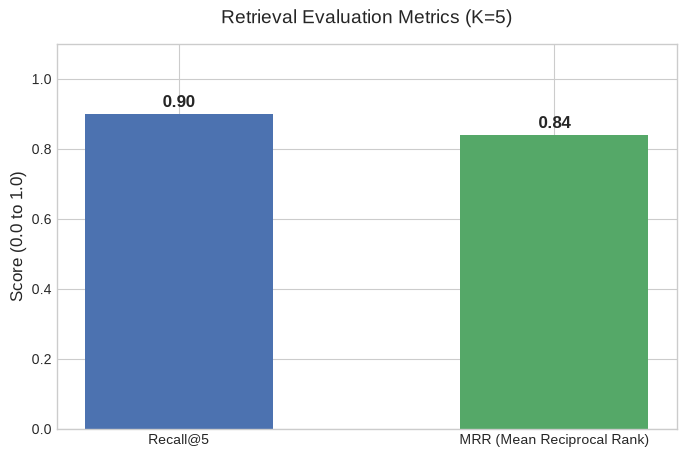

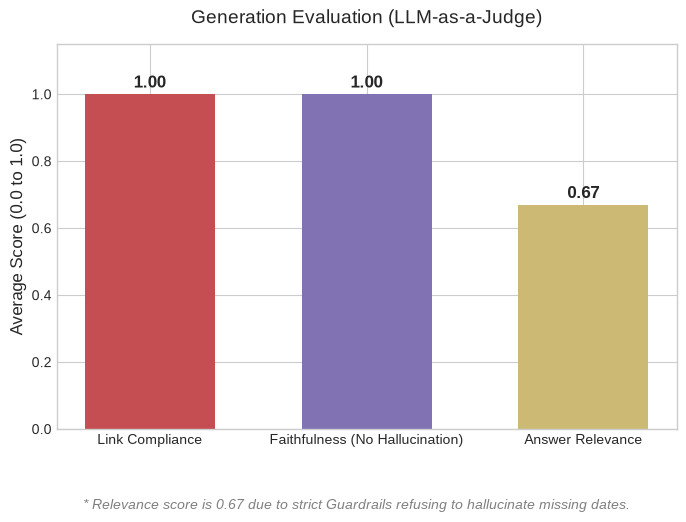

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# إعدادات الخطوط والألوان للرسم
plt.style.use('seaborn-v0_8-whitegrid')

# ==========================================
# المخطط الأول: نتائج تقييم الاسترجاع (Retrieval)
# ==========================================
retrieval_metrics = ['Recall@5', 'MRR (Mean Reciprocal Rank)']
retrieval_scores = [0.90, 0.84]

plt.figure(figsize=(8, 5))
bars = plt.bar(retrieval_metrics, retrieval_scores, color=['#4C72B0', '#55A868'], width=0.5)
plt.ylim(0, 1.1)
plt.title('Retrieval Evaluation Metrics (K=5)', fontsize=14, pad=15)
plt.ylabel('Score (0.0 to 1.0)', fontsize=12)

# كتابة الأرقام فوق الأعمدة
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f"{yval:.2f}", ha='center', fontsize=12, fontweight='bold')

plt.savefig('retrieval_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

# ==========================================
# المخطط الثاني: نتائج تقييم التوليد (Generation)
# ==========================================
generation_metrics = ['Link Compliance', 'Faithfulness (No Hallucination)', 'Answer Relevance']
generation_scores = [1.00, 1.00, 0.67] # 0.67 بسبب تجنب النموذج لاختراع إجابات غير موجودة

plt.figure(figsize=(8, 5))
bars = plt.bar(generation_metrics, generation_scores, color=['#C44E52', '#8172B3', '#CCB974'], width=0.6)
plt.ylim(0, 1.15)
plt.title('Generation Evaluation (LLM-as-a-Judge)', fontsize=14, pad=15)
plt.ylabel('Average Score (0.0 to 1.0)', fontsize=12)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f"{yval:.2f}", ha='center', fontsize=12, fontweight='bold')

# إضافة ملاحظة توضيحية للمخطط
plt.figtext(0.5, -0.05, "* Relevance score is 0.67 due to strict Guardrails refusing to hallucinate missing dates.", ha="center", fontsize=10, style='italic', color='gray')

plt.savefig('generation_metrics.png', dpi=300, bbox_inches='tight')
plt.show()